# TD3: Loi de Fourier de la diffusion de la chaleur: inversion de très grosses matrices

# I

## Question 1

L'évolution de la température au sein du système est régie par la loi de diffusion:
$$\rho C_p\frac{\partial T}{\partial t}-\nabla .(\kappa\nabla T)=\dot{Q}$$
En combinant les équations données, et en supposant que le matériau est homogène et la conductivité constante, on obtient :
$$-\kappa\Delta T=\dot{Q}$$

## Question 2

On peut approximer les dérivées premières de la manière suivante:
$$\frac{\partial T(x+\frac{\delta}{2},y)}{\partial x}=\frac{T(x+\delta,y)-T(x,y)}{\delta}$$

$$\frac{\partial T(x,y+\frac{\delta}{2})}{\partial y}=\frac{T(x,y+\delta)-T(x,y)}{\delta}$$
De même, on approxime les dérivées secondes et l'EDP discrétisée se réecrit:
$$-\frac{\kappa}{\delta^2}(T_{i+1,j}+T_{i,j+1}-4T_{i,j}+T_{i-1,j}+T_{i,j-1})=\dot{Q_{i,j}}$$

## Question 3

On a $$L_x=n_x\delta$$ et $$L_y=n_y\delta$$ 

Afin d'utiliser un vecteur colonne et non une matrice, on introduit l'indice composé $l=i+(n_x+1)j$ 

$j=l //(n_x+1)$ (quotient dans la division euclidienne de $l$ par $n_x+1$) et $i = l$%($n_x$+1) (reste dans la division euclidienne de $l$ par $n_x+1$).

Par unicité de la division euclidienne de $l$ par $n_x+1$, il y a une correspondance bi-univoque entre les entiers $l$ et les couples $(i,j)$.

Ainsi, la température du conducteur en tout point de coordonnées $(i,j)$ dans le plan Oxy est la composante $l(i,j)$ du vecteur T.

## Question 4

On peut réecrire l'EDP discrétisée $$-\frac{\kappa}{\delta^2}(T_{i+1,j}+T_{i,j+1}-4T_{i,j}+T_{i-1,j}+T_{i,j-1})=\dot{Q_{i,j}}$$ 
par la relation :
$$-\frac{\kappa}{\delta^2}(T_{i+1+(n_x+1)j}+T_{i+(n_x+1)(j+1)}-4T_{i+(n_x+1)j}+T_{i-1+(n_x+1)j}+T_{i+(n_x+1)(j-1)})=\dot{Q_{i,j}}$$

La matrice A est composée de 5 diagonales non nulles:
pour tout $1\le p\le l_{max}+1$ avec $l_{max}$=$n_x$+($n_x$+1)$n_y$, $$A_{p,p-n_x} =1$$ 
$$A_{p,p} =1$$
$$A_{p,p+1} =-4$$
$$A_{p,p+2} =1$$
$$A_{p,p+2+n_x} =1$$

C'est à dire que la p-$n_x$ième sous-diagonale est remplie de 1, la diagonale de A, la 2ème sur-diagonale et la p+2+$n_x$ième sur-diagonale également; et la 1ère sur-diagonale est composée de -4.

Le reste des coefficients de A sont égaux à 0, elle peut donc être considérée comme creuse car seules 5 diagonales sont non nulles.

# II

In [63]:
"""importation des modules"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["figure.figsize"]=[7,6]

## Question 1

Si $n_x$=20 et $n_y$=20, $l$ varie de 0 pour (i,j)=(0,0) à $l_{max}=440$ pour (i,j)=$(n_x, n_y)$= (20,20).

Donc la matrice carrée A possède $(l_{max}+1)^{2}$=194'481 éléments.

D'après l'étude des coefficients de A réalisée à la question précédente, il y a :

- $(l_{max}+1)- n_x$ termes $A_{p,p-n_x} =1$ 

- $(l_{max}+1)$ termes $A_{p,p} =1$

- $(l_{max}+1)- 1$ termes $A_{p,p+1} =-4$

- $(l_{max}+1)- 2$ termes $A_{p,p+2} =1$

- $(l_{max}+1)- n_x - 2$ termes $A_{p,p+2+n_x} =1$

soit $5(l_{max}+1)- 2n_x -5$ éléments non nuls donc 2160 éléments sur 194'481 (=1.11%).


## Question 2

En développant l'équation (3.9) et en repassant en terme matricielle, on obtient:
$$4X_{i,j}^{p+1}=X_{i-1,j}^{p+1}+X_{i,j-1}^{p+1}+X_{i+1,j}^p+X_{i,j+1}^p+\frac{\delta^2}{\kappa}Q'_{i,j}$$
On peut donc construire le vecteur $X^{p+1}$ à l'aide d'une double boucle for et de la connaissance de $X^p$ .

# Question 3

In [64]:
def champT(nx,ny):
    Q=np.zeros((nx+1,ny+1)) #Q est maintenu nul partout
    n_max=10000  #définition des paramètres
    L=1
    delta=L/nx
    eps=10**(-3)
    x0=np.array([[300.]*(ny+1) for i in range(nx+1)]) #la température est initialement de 300 partout
    for i in range(nx+1): #conditions aux bords:
            x0[i,0]=400.  #T=400 pour y=0
            x0[i,ny]=400. #T=400 pour y=L
    x_p=x0 
    b=True
    k=0
    while k<n_max and b: #tant que le nombre d'itération effectué est inférieur à n_max et que b est vrai
        x_p1=np.zeros((nx+1,ny+1)) #vecteur X_(p+1)
        for i in range(nx+1): #conditions aux bords pour X_(p+1):
            x_p1[i,0]=400.    #T=400 pour y=0
            x_p1[i,ny]=400.   #T=400 pour y=L
        for j in range(ny+1):
            x_p1[0,j]=300.    #T=300 pour x=0
            x_p1[nx,j]=300.   #T=300 pour x=L
        for j in range(1,ny):
            for i in range(1,nx):
                x_p1[i,j]=0.25*(x_p1[i-1,j]+x_p1[i,j-1]+x_p[i+1,j]+x_p[i,j+1]+delta**2*Q[i,j])
        b=np.amax(np.absolute(x_p1-x_p))>=eps #affirmation b
        x_p=x_p1 
        k+=1
    return x_p


## Questions 4 et 5

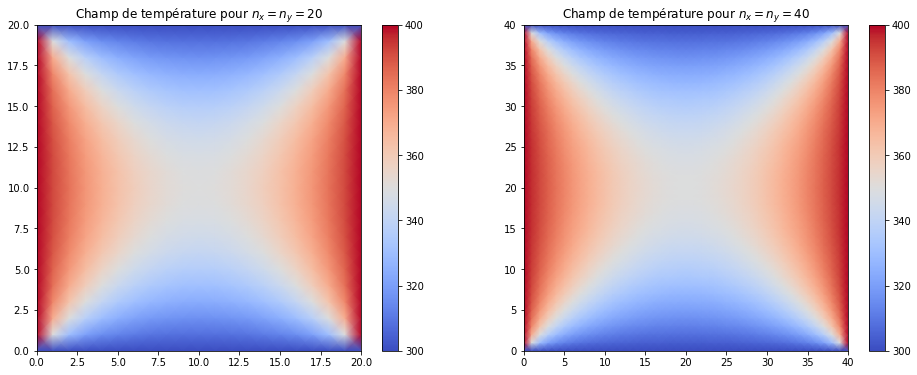

In [65]:
plt.subplots(figsize=(16, 6)) 
plt.subplot(1, 2, 1) 
plt.pcolormesh(champT(20,20),cmap=plt.cm.coolwarm,shading='gouraud')
plt.title("Champ de température pour $n_x=n_y=20$")
plt.colorbar()
plt.subplot(1, 2, 2) 
plt.pcolormesh(champT(40,40),cmap=plt.cm.coolwarm,shading='gouraud')
plt.title("Champ de température pour $n_x=n_y=40$")
plt.colorbar()
plt.show()

Pour $n_x=n_y=40$, les frontières entre chaud et froid sont dessinées plus précisement avec davantage de points.

## Question 6

On va représenter le gradient de température en 2 dimensions par 2 matrices Tx et Ty représentant les coordonnées selon x et y de ce gradient. Les points de la matrice Tx sont calculés grace à l'égalité: 

$$\frac{\partial T}{\partial x}\simeq\frac{T(x+\delta)-T(x-\delta)}{2\delta}$$

De même pour Ty. Enfin, on prend comme condition aux bords que le flux y est nul.

Pour rappel : $K=1$.

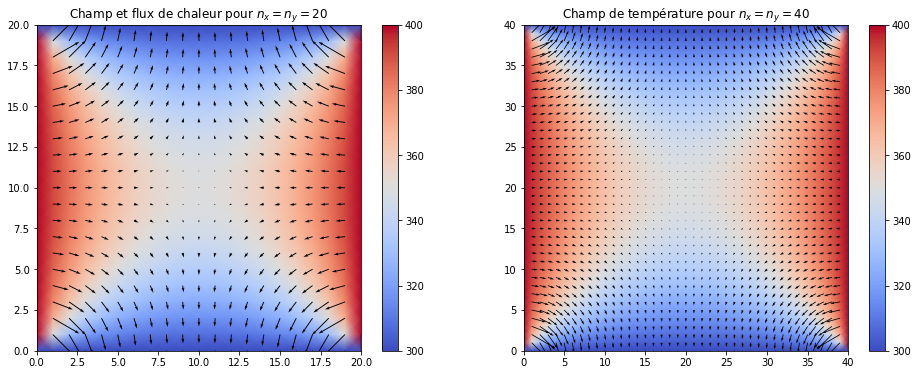

In [66]:
def flux_de_T(T,nx,ny):
    delta=1/nx
    Tx=np.zeros((nx+1,ny+1))
    Ty=np.zeros((nx+1,ny+1))
    for j in range(ny+1):
        for i in range(1,nx):
            Tx[i,j]=-(T[i+1,j]-T[i-1,j])/(2*delta)
    for i in range(nx+1):
        for j in range(1,ny):
            Ty[i,j]=-(T[i,j+1]-T[i,j-1])/(2*delta)
    return Tx,Ty

T1=champT(20,20)
T2=champT(40,40)

plt.subplots(figsize=(16, 6)) 

plt.subplot(1, 2, 1) 
plt.pcolormesh(T,cmap=plt.cm.coolwarm,shading='gouraud')
plt.title("Champ et flux de chaleur pour $n_x=n_y=20$")
Tx,Ty=flux_de_T(T1,20,20)
plt.colorbar()
plt.quiver(Ty,Tx)

plt.subplot(1, 2, 2) 
plt.pcolormesh(T2,cmap=plt.cm.coolwarm,shading='gouraud')
plt.title("Champ de température pour $n_x=n_y=40$")
Tx,Ty=flux_de_T(T2,40,40)
plt.colorbar()
plt.quiver(Ty,Tx)

plt.show()

## Question 7 et 8

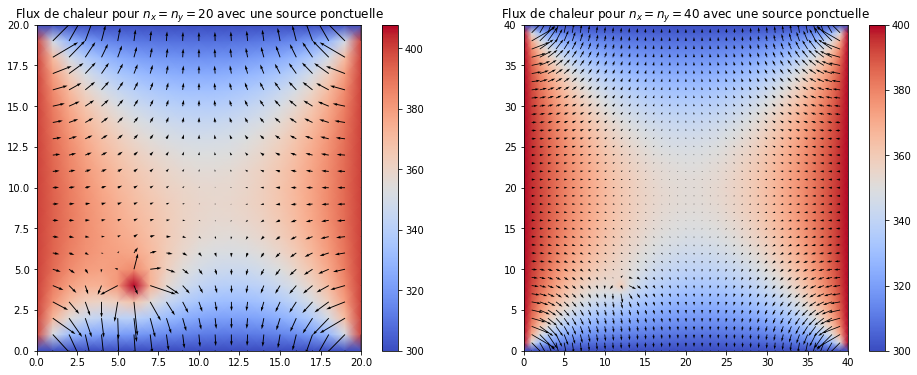

In [67]:
def champT_et_source(nx,ny):
    Q=np.zeros((nx+1,ny+1)) #Q est maintenu nul partout
    Q[int(.2*nx),int(.3*ny)]=5*10**4 
    n_max=10000  #définition des paramètres
    L=1 
    delta=L/nx
    eps=10**(-3)
    x0=np.array([[300.]*(nx+1) for i in range(ny+1)]) #la température est initialement de 300 partout
    for i in range(nx+1): #conditions aux bords:
            x0[i,0]=400.  #T=400 pour y=0
            x0[i,ny]=400. #T=400 pour y=L
    x_p=x0 
    b=True
    k=0
    while k<n_max and b: #tant que le nombre d'itération effectué est inférieur à n_max et que b est vrai
        x_p1=np.zeros((nx+1,ny+1)) #vecteur X_(p+1)
        for i in range(nx+1): #conditions aux bords pour X_(p+1):
            x_p1[i,0]=400.    #T=400 pour y=0
            x_p1[i,ny]=400.   #T=400 pour y=L
        for j in range(ny+1):
            x_p1[0,j]=300.    #T=300 pour x=0
            x_p1[nx,j]=300.   #T=300 pour x=L
        for j in range(1,ny):
            for i in range(1,nx):
                x_p1[i,j]=0.25*(x_p1[i-1,j]+x_p1[i,j-1]+x_p[i+1,j]+x_p[i,j+1]+delta**2*Q[i,j])
        b=np.amax(np.absolute(x_p1-x_p))>=eps #affirmation b
        x_p=x_p1 
        k+=1
    return x_p

T3=champT_et_source(20,20)
T4=champT_et_source(40,40)

plt.subplots(figsize=(16, 6)) 

plt.subplot(1, 2, 1) 
plt.pcolormesh(T3,cmap=plt.cm.coolwarm,shading='gouraud')
plt.title("Flux de chaleur pour $n_x=n_y=20$ avec une source ponctuelle")
Tx,Ty=flux_de_T(T3,20,20)
plt.colorbar()
plt.quiver(Ty,Tx)

plt.subplot(1, 2, 2) 
plt.pcolormesh(T4,cmap=plt.cm.coolwarm,shading='gouraud')
plt.title("Flux de chaleur pour $n_x=n_y=40$ avec une source ponctuelle")
Tx,Ty=flux_de_T(T4,40,40)
plt.colorbar()
plt.quiver(Ty,Tx)

plt.show()


Le profil de température est différent et ceci est cohérent. 
En effet, plus la résolution est mauvaise, plus la source ponctuelle occupe une partie importante de l'espace et donc plus le gradient de température à son voisinage est élevé. 

Changer de résolution revient donc à changer de source et on ne résout plus le même problème physique. Il est normal que les températures soient différentes.

## Question 9

On va représenter un trou centré en (i,j)=(20,20).

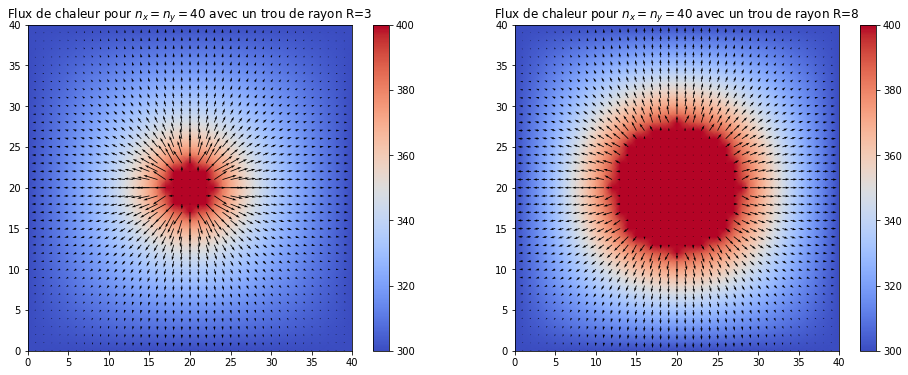

In [68]:
def dans_le_cercle(i,j,R):
    if ((j-20)**2+(i-20)**2)**0.5<=R:
        return True
    return False


def champ_et_trou(nx,ny,R):
    Q=np.zeros((nx+1,ny+1)) #Q est maintenu nul partout
    n_max=10000  #définition des paramètres
    L=1
    delta=L/nx
    eps=10**(-3)
    x0=np.array([[300.]*(ny+1) for i in range(nx+1)]) #la température est initialement de 300 partout
    for i in range(nx+1): 
            for j in range(ny+1):  
                if dans_le_cercle(i,j,R)==True:
                    x0[i,j]=400. #T=400 dans le trou
    x_p=x0 
    b=True
    k=0
    while k<n_max and b: #tant que le nombre d'itération effectué est inférieur à n_max et que b est vrai
        x_p1=np.zeros((nx+1,ny+1)) #vecteur X_(p+1)
        for i in range(nx+1): 
            x_p1[i,0]=300.    #T=300 pour y=0
            x_p1[i,ny]=300.   #T=300 pour y=L
        for j in range(ny+1):
            x_p1[0,j]=300.    #T=300 pour x=0
            x_p1[nx,j]=300.   #T=300 pour x=L
        for j in range(1,ny):
            for i in range(1,nx):
                if dans_le_cercle(i,j,R)==True:
                    x_p1[i,j]=400
                else:
                    x_p1[i,j]=0.25*(x_p1[i-1,j]+x_p1[i,j-1]+x_p[i+1,j]+x_p[i,j+1]+delta**2*Q[i,j])
        b=np.amax(np.absolute(x_p1-x_p))>=eps #affirmation b
        x_p=x_p1 
        k+=1
    return x_p

n=40

T5=champ_et_trou(n,n,3)
T6=champ_et_trou(n,n,8)

plt.subplots(figsize=(16, 6)) 

plt.subplot(1, 2, 1) 
plt.pcolormesh(T5,cmap=plt.cm.coolwarm,shading='gouraud')
plt.title("Flux de chaleur pour $n_x=n_y=40$ avec un trou de rayon R=3")
Tx,Ty=flux_de_T(T5,n,n)
plt.colorbar()
plt.quiver(Ty,Tx)


plt.subplot(1, 2, 2) 
plt.pcolormesh(T6,cmap=plt.cm.coolwarm,shading='gouraud')
plt.title("Flux de chaleur pour $n_x=n_y=40$ avec un trou de rayon R=8")
Tx,Ty=flux_de_T(T6,n,n)
plt.colorbar()
plt.quiver(Ty,Tx)


plt.show()

## Question 10

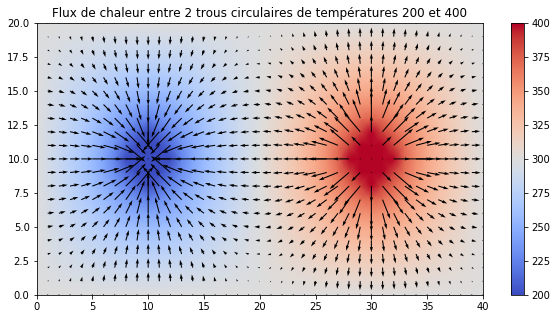

In [69]:
def dans_cercle1(i,j,R):
    if ((j-10)**2+(i-10)**2)**(.5)<=R:
        return True
    return False

def dans_cercle2(i,j,R):
    if ((j-30)**2+(i-10)**2)**(.5)<=R:
        return True
    return False

def champ_et_2trous(nx,ny,R,T1,T2):
    Q=np.zeros((nx+1,ny+1)) #Q est maintenu nul partout
    n_max=10000  #définition des paramètres
    L=1
    delta=L/nx
    eps=10**(-3)
    x0=np.array([[300.]*(ny+1) for i in range(nx+1)]) #la température est initialement de 300 partout
    for i in range(nx+1): 
            for j in range(ny+1):  
                if dans_cercle1(i,j,R)==True:
                    x0[i,j]=T1   #T=400 dans le trou
                if dans_cercle2(i,j,R)==True:
                    x0[i,j]=T2
    x_p=x0 
    b=True
    k=0
    while k<n_max and b: #tant que le nombre d'itération effectué est inférieur à n_max et que b est vrai
        x_p1=np.zeros((nx+1,ny+1)) #vecteur X_(p+1)
        for i in range(nx+1): 
            x_p1[i,0]=300.    #T=300 pour y=0
            x_p1[i,ny]=300.   #T=300 pour y=L
        for j in range(ny+1):
            x_p1[0,j]=300.    #T=300 pour x=0
            x_p1[nx,j]=300.   #T=300 pour x=L
        for j in range(1,ny):
            for i in range(1,nx):
                if dans_cercle1(i,j,R)==True:
                    x_p1[i,j]=T1
                elif dans_cercle2(i,j,R)==True:
                    x_p1[i,j]=T2
                else:
                    x_p1[i,j]=0.25*(x_p1[i-1,j]+x_p1[i,j-1]+x_p[i+1,j]+x_p[i,j+1]+delta**2*Q[i,j])
        b=np.amax(np.absolute(x_p1-x_p))>=eps #affirmation b
        x_p=x_p1 
        k+=1
    return x_p

R=2
T7=champ_et_2trous(20,40,R,200,400)
mpl.rcParams["figure.figsize"]=[10,5]
plt.pcolormesh(T7,cmap=plt.cm.coolwarm,shading='gouraud')
plt.title("Flux de chaleur entre 2 trous circulaires de températures 200 et 400")
Tx,Ty=flux_de_T(T7,20,40)
plt.colorbar()
plt.quiver(Ty,Tx)

plt.show()


On observe que le gradient de température va bien de la source chaude vers la source froide. 